In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, confusion_matrix, roc_curve, auc,
    ConfusionMatrixDisplay, make_scorer
)

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

%matplotlib inline
plt.style.use('seaborn-v0_8')

In [2]:
df = pd.read_csv("/home/muthu/Desktop/Classifier_PI/CTD_dataset/merged_PIs_nonPIs_CTD_feat_.csv")

X = df.drop(columns=["label"])
y = df["label"]

X_train_cv, X_test, y_train_cv, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

neg, pos = (y_train_cv == 0).sum(), (y_train_cv == 1).sum()
scale_pos_weight = neg / pos if pos > 0 else 1
print(f"Negative:Positive ratio → {scale_pos_weight:.2f}")
print(f"Training set: {X_train_cv.shape[0]:,} | Test set: {X_test.shape[0]:,}")

Negative:Positive ratio → 2.16
Training set: 18,101 | Test set: 4,526


In [3]:
models = {
    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        scale_pos_weight=scale_pos_weight,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'mcc': make_scorer(matthews_corrcoef)
}

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "mcc": matthews_corrcoef(y_true, y_pred)
    }

def stacking_cv_per_fold(base_models_dict, X, y, n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_results = []
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        print(f"Stacking Fold {fold}/{n_splits}")
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        trained_models = {}
        for name, model in base_models_dict.items():
            clf = clone(model)
            clf.fit(X_tr, y_tr)
            trained_models[name] = clf
        meta_train = np.column_stack([trained_models[name].predict_proba(X_tr)[:, 1] for name in base_models_dict])
        meta_val = np.column_stack([trained_models[name].predict_proba(X_val)[:, 1] for name in base_models_dict])
        meta_learner = LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1)
        meta_learner.fit(meta_train, y_tr)
        val_probs = meta_learner.predict_proba(meta_val)[:, 1]
        metrics = compute_metrics(y_val, val_probs)
        metrics["fold"] = fold
        fold_results.append(metrics)
    return pd.DataFrame(fold_results)

per_fold_results = stacking_cv_per_fold(models, X_train_cv, y_train_cv, n_splits=5)

summary = per_fold_results.drop(columns="fold").agg(["mean", "std"]).T.round(4)
summary["mean ± std"] = summary["mean"].astype(str) + " ± " + summary["std"].astype(str)

print("Stacking Per-Fold CV Metrics:")
display(per_fold_results)

print("\nStacking CV Summary (Mean ± Std):")
display(summary[["mean ± std"]])

Stacking Fold 1/5
Stacking Fold 2/5
Stacking Fold 3/5
Stacking Fold 4/5
Stacking Fold 5/5
Stacking Per-Fold CV Metrics:


,accuracy,precision,recall,f1,roc_auc,mcc,fold
0,0.914112,0.901829,0.817627,0.857666,0.960664,0.798339,1
1,0.919061,0.896007,0.842059,0.868196,0.964638,0.810689,2
2,0.912431,0.890669,0.824607,0.856366,0.965350,0.794735,3
3,0.912431,0.881325,0.835951,0.858039,0.961822,0.795371,4
4,0.918785,0.895911,0.841187,0.867687,0.966358,0.810018,5



Stacking CV Summary (Mean ± Std):


,mean ± std
accuracy,0.9154 ± 0.0033
precision,0.8931 ± 0.0077
recall,0.8323 ± 0.0107
f1,0.8616 ± 0.0058
roc_auc,0.9638 ± 0.0024
mcc,0.8018 ± 0.0079


In [5]:
final_base_models = [clone(models[name]) for name in models]

for model in final_base_models:
    model.fit(X_train_cv, y_train_cv)

meta_full = np.column_stack([
    model.predict_proba(X_train_cv)[:, 1]
    for model in final_base_models
])

final_meta_learner = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)
final_meta_learner.fit(meta_full, y_train_cv)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)

In [6]:
class StackingEnsemble:
    def __init__(self, base_models, meta_model):
        self.base_models = base_models
        self.meta_model = meta_model
    
    def predict_proba(self, X):
        meta_features = np.column_stack([
            model.predict_proba(X)[:, 1]
            for model in self.base_models
        ])
        return self.meta_model.predict_proba(meta_features)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)

stacking_model = StackingEnsemble(final_base_models, final_meta_learner)

test_probs = stacking_model.predict_proba(X_test)[:, 1]
test_metrics = compute_metrics(y_test, test_probs)

print("\nFinal Stacking Model - Testset:")
display(pd.Series(test_metrics).to_frame("Score").round(4))


Final Stacking Model - Testset:


,Score
accuracy,0.9200
precision,0.8906
recall,0.8521
f1,0.8709
roc_auc,0.9693
mcc,0.8134


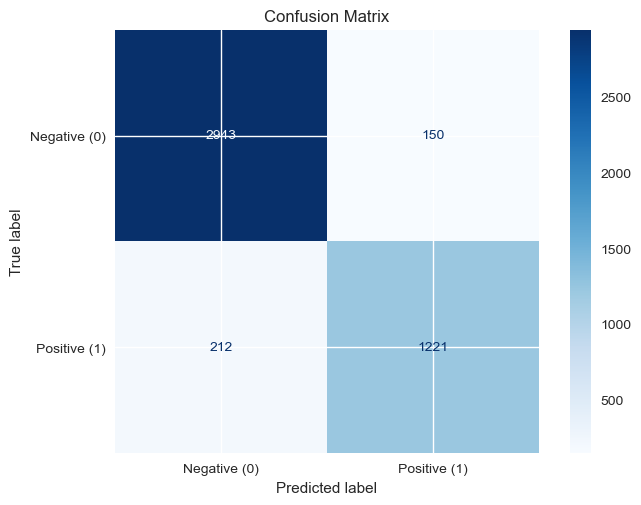

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_test_pred = stacking_model.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative (0)", "Positive (1)"])
disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix")
plt.show()

In [8]:
import joblib
import os

os.makedirs("metamodel_saved", exist_ok=True)
joblib.dump(stacking_model, "metamodel_saved/stacking_meta_model_CTD_feat.pkl")

['metamodel_saved/stacking_meta_model_CTD_feat.pkl']

In [9]:
import pandas as pd

unseen_df = pd.read_csv("MAPH_CTD_feat.csv")

ids = unseen_df.iloc[:, 0]

X_unseen = unseen_df.iloc[:, 1:]


In [10]:
import joblib

stacking_model = joblib.load("metamodel_saved/stacking_meta_model_CTD_feat.pkl")


In [11]:

y_unseen_prob = stacking_model.predict_proba(X_unseen)[:, 1]


y_unseen_pred = stacking_model.predict(X_unseen)

output_df = pd.DataFrame({
    "ID": ids,
    "probability": y_unseen_prob,
    "prediction": y_unseen_pred
})

output_df.to_csv("stacking_predictions_comp_feat.csv", index=False)


In [12]:
print(output_df.head())
print(output_df["prediction"].value_counts())


       ID  probability  prediction
0  K2QGL0     0.001399           0
1  K2QIM2     0.000573           0
2  K2QIQ7     0.999705           1
3  K2QIZ1     0.000289           0
4  K2QIZ9     0.999725           1
prediction
1    250
0    187
Name: count, dtype: int64
